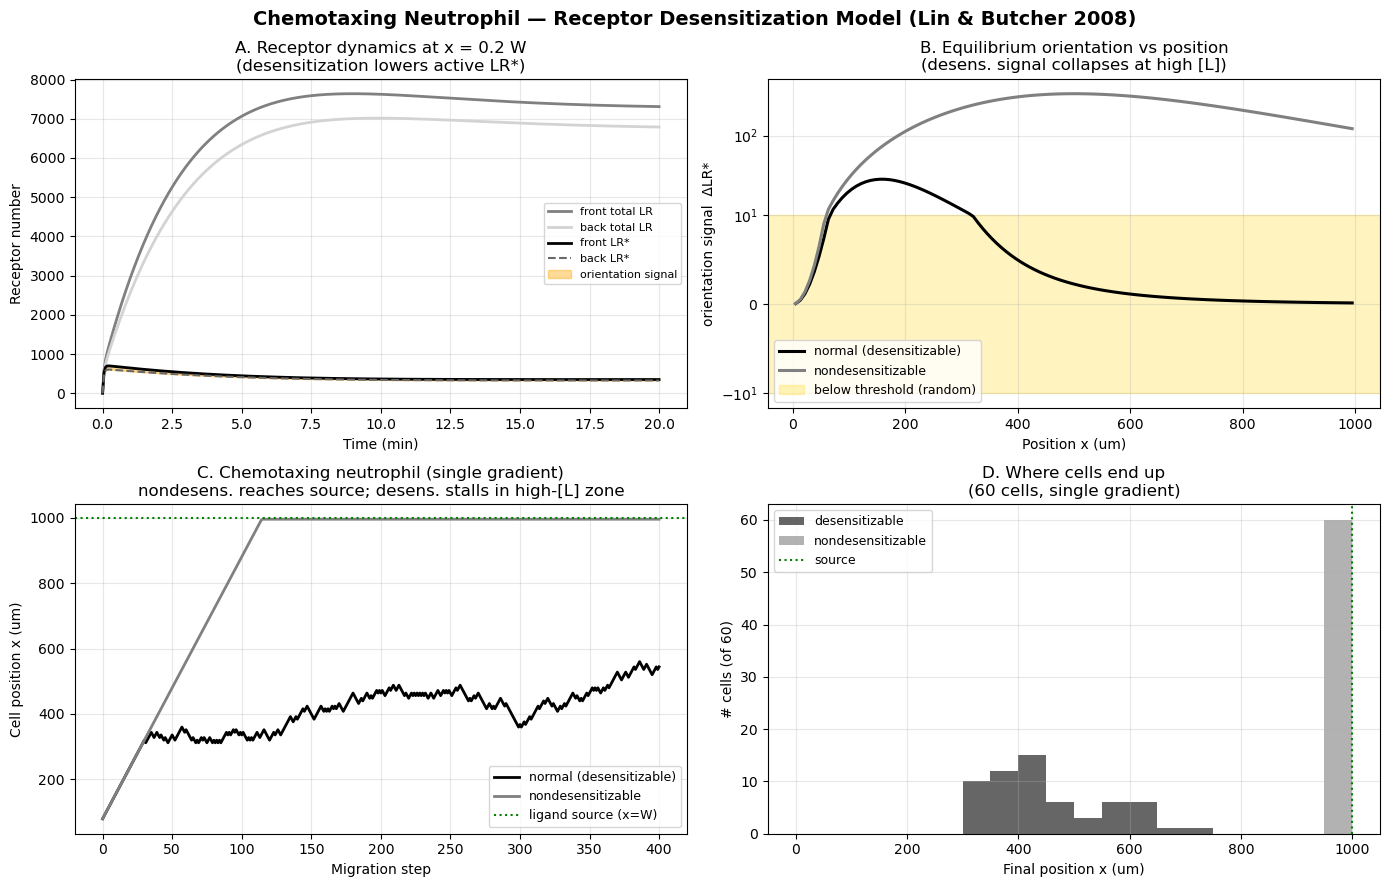

kd = kr1/kf = 4.40 nM   (mean [L] over field = kd)
orientation threshold |ΔLR*| >= 10 receptors
Equilibrium orientation signal ΔLR* (front − back):
 x(um)    desens   nondesens
    50       6.2         7.5
   100      20.1        29.8
   150      28.3        65.7
   200      25.4       112.6
   300      11.9       219.7
   500       2.3       333.2
   700       0.6       261.3
   900       0.2       158.5
=> single gradient: both receptor types orient up-gradient,
   but the desensitizable signal peaks (~28) then falls below
   threshold at high [L] (saturation) — so the cell loses
   directional information near the source. The nondesensitizable
   signal grows monotonically and stays well above threshold.
   (The functional advantage of desensitization appears in
    COMPETING gradients — the next question.)


In [1]:
"""
Week 3 – Physics of Molecular Diseases
Chemotaxing Neutrophil  (Lin & Butcher, J. Immunol. 2008)
=====================================================
Receptor-mediated orientation model with homologous desensitization.

Cell = two receptor units (front/back), separated by l = 10 um.
Each unit obeys (Eqs 1-3, conservation Eq 4):
    R + L <kf,kr1> LR*  --kdes--> LRd  --ki--> (LRi -> Ri instantly)
    Ri --kup--> R                        (recycling / up-regulation)

State per unit: [LR*, LRd, R] ;  Ri = Rtot - R - LR* - LRd

Orientation signal (Eq 10):  dLR* = LR*_front - LR*_back
Cell orients up-gradient if dLR* >= +threshold, down if <= -threshold,
else random migration.   threshold = 10 receptors.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================================
# PARAMETERS (formyl-peptide receptor on neutrophils)
# ============================================================
P = dict(kf=8.4e7,     # M^-1 s^-1  ligand-receptor association
         kr1=0.37,     # s^-1       low-affinity dissociation
         kdes=0.065,   # s^-1       desensitization (0 for nondesensitizable)
         ki=0.0033,    # s^-1       internalization
         kup=0.004,    # s^-1       up-regulation / recycling
         Rtot=25000.0) # receptors per unit (front or back)

Lmax = 17.6e-9   # M    peak ligand (mean over field = kd)
W    = 1000.0    # um   gradient width
n    = 3.0       # gradient nonlinearity
l    = 10.0      # um   cell length (front-back separation)
thr  = 10.0      # receptors; orientation threshold |dLR*| >= 10
kd   = P['kr1']/P['kf']   # = 4.4 nM

def Lgrad(x):
    """Single-ligand gradient profile (Eq 14, L0 = 0). Source at x = W."""
    return Lmax * (np.clip(x, 0, W)/W)**n

# ============================================================
# RECEPTOR DYNAMICS (one unit)
# ============================================================
def rhs(t, s, L, p):
    LRs, LRd, R = s
    Ri = p['Rtot'] - R - LRs - LRd
    a  = p['kf']*L
    dLRs = a*R - (p['kr1'] + p['kdes'])*LRs
    dLRd = p['kdes']*LRs - p['ki']*LRd
    dR   = p['kr1']*LRs - a*R + p['kup']*Ri
    return [dLRs, dLRd, dR]

def trajectory_unit(L, p, T, t_eval):
    """Time course of [LR*, LRd, R] for one unit at constant ligand L."""
    return solve_ivp(rhs, (0, T), [0, 0, p['Rtot']], args=(L, p),
                     t_eval=t_eval, rtol=1e-8, atol=1e-6).y

def steady_LRstar(L, p, T=4000):
    """Equilibrium number of active complexes LR* for one unit."""
    return solve_ivp(rhs, (0, T), [0, 0, p['Rtot']], args=(L, p),
                     rtol=1e-8, atol=1e-6).y[0, -1]

def orientation_signal(x, p):
    """dLR* = LR*_front(right) - LR*_back(left) at steady state."""
    return steady_LRstar(Lgrad(x + l/2), p) - steady_LRstar(Lgrad(x - l/2), p)

# ============================================================
# MIGRATION: chemotaxing neutrophil
# ============================================================
def chemotax(x_grid, signal_grid, x0=80, steps=400, ds=8.0, seed=1):
    """
    Quasi-static walk: at each step read the equilibrium orientation
    signal at the current position and move accordingly.
    """
    rng = np.random.default_rng(seed)
    x = x0
    path = [x]
    for _ in range(steps):
        d = np.interp(x, x_grid, signal_grid)
        if d >= thr:      x += ds                      # orient up-gradient
        elif d <= -thr:   x -= ds                      # orient down-gradient
        else:             x += rng.choice([-1, 1])*ds  # random migration
        x = np.clip(x, 5, W-5)
        path.append(x)
    return np.array(path)

# ============================================================
# FIGURE
# ============================================================
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

# ---- Panel A: Fig 1A — receptor dynamics at x = 0.2 W ----
x0 = 0.2*W
t_eval = np.linspace(0, 1200, 400)          # 0-20 min, in seconds
yf = trajectory_unit(Lgrad(x0 + l/2), dict(P), 1200, t_eval)
yb = trajectory_unit(Lgrad(x0 - l/2), dict(P), 1200, t_eval)
tot_f, tot_b = yf[0]+yf[1], yb[0]+yb[1]      # total LR = LR* + LRd
tmin = t_eval/60.0
ax[0,0].plot(tmin, tot_f, color='gray', lw=2, label='front total LR')
ax[0,0].plot(tmin, tot_b, color='lightgray', lw=2, label='back total LR')
ax[0,0].plot(tmin, yf[0], color='k', lw=2, label='front LR*')
ax[0,0].plot(tmin, yb[0], color='dimgray', lw=1.5, ls='--', label='back LR*')
ax[0,0].fill_between(tmin, yf[0], yb[0], color='orange', alpha=0.4, label='orientation signal')
ax[0,0].set_xlabel('Time (min)'); ax[0,0].set_ylabel('Receptor number')
ax[0,0].set_title('A. Receptor dynamics at x = 0.2 W\n(desensitization lowers active LR*)')
ax[0,0].legend(fontsize=8); ax[0,0].grid(alpha=0.3)

# ---- Panel B: Fig 1B — equilibrium dLR* vs position ----
xs = np.linspace(5, W-5, 120)
gD = np.array([orientation_signal(x, dict(P, kdes=0.065)) for x in xs])  # desensitizable
gN = np.array([orientation_signal(x, dict(P, kdes=0.0))   for x in xs])  # nondesensitizable
ax[0,1].plot(xs, gD, color='k',   lw=2.2, label='normal (desensitizable)')
ax[0,1].plot(xs, gN, color='gray',lw=2.2, label='nondesensitizable')
ax[0,1].axhspan(-thr, thr, color='gold', alpha=0.25, label='below threshold (random)')
ax[0,1].set_xlabel('Position x (um)'); ax[0,1].set_ylabel('orientation signal  ΔLR*')
ax[0,1].set_title('B. Equilibrium orientation vs position\n(desens. signal collapses at high [L])')
ax[0,1].legend(fontsize=9); ax[0,1].grid(alpha=0.3); ax[0,1].set_yscale('symlog', linthresh=10)

# ---- Panel C: migration trajectories ----
pD = chemotax(xs, gD, seed=1)
pN = chemotax(xs, gN, seed=1)
ax[1,0].plot(pD, color='k',    lw=2, label='normal (desensitizable)')
ax[1,0].plot(pN, color='gray', lw=2, label='nondesensitizable')
ax[1,0].axhline(W, color='green', ls=':', lw=1.5, label='ligand source (x=W)')
ax[1,0].set_xlabel('Migration step'); ax[1,0].set_ylabel('Cell position x (um)')
ax[1,0].set_title('C. Chemotaxing neutrophil (single gradient)\nnondesens. reaches source; desens. stalls in high-[L] zone')
ax[1,0].legend(fontsize=9); ax[1,0].grid(alpha=0.3)

# ---- Panel D: final-position distribution over many cells ----
endD = [chemotax(xs, gD, seed=s)[-1] for s in range(60)]
endN = [chemotax(xs, gN, seed=s)[-1] for s in range(60)]
ax[1,1].hist(endD, bins=20, range=(0,W), alpha=0.6, color='k',    label='desensitizable')
ax[1,1].hist(endN, bins=20, range=(0,W), alpha=0.6, color='gray', label='nondesensitizable')
ax[1,1].axvline(W, color='green', ls=':', lw=1.5, label='source')
ax[1,1].set_xlabel('Final position x (um)'); ax[1,1].set_ylabel('# cells (of 60)')
ax[1,1].set_title('D. Where cells end up\n(60 cells, single gradient)')
ax[1,1].legend(fontsize=9); ax[1,1].grid(alpha=0.3)

plt.suptitle('Chemotaxing Neutrophil — Receptor Desensitization Model (Lin & Butcher 2008)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# CONSOLE SUMMARY
# ============================================================
print("="*60)
print(f"kd = kr1/kf = {kd*1e9:.2f} nM   (mean [L] over field = kd)")
print(f"orientation threshold |ΔLR*| >= {thr:.0f} receptors")
print("="*60)
print("Equilibrium orientation signal ΔLR* (front − back):")
print(f"{'x(um)':>6}{'desens':>10}{'nondesens':>12}")
for x in [50,100,150,200,300,500,700,900]:
    print(f"{x:>6}{orientation_signal(x,dict(P,kdes=0.065)):>10.1f}"
          f"{orientation_signal(x,dict(P,kdes=0.0)):>12.1f}")
print("="*60)
print("=> single gradient: both receptor types orient up-gradient,")
print("   but the desensitizable signal peaks (~28) then falls below")
print("   threshold at high [L] (saturation) — so the cell loses")
print("   directional information near the source. The nondesensitizable")
print("   signal grows monotonically and stays well above threshold.")
print("   (The functional advantage of desensitization appears in")
print("    COMPETING gradients — the next question.)")
print("="*60)